In [2]:
!pip install niapy
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib import pyplot
from pandas import read_csv
from pandas.plotting import scatter_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
from sklearn.ensemble import RandomForestClassifier
# importing utility modules
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
# importing machine learning models for prediction
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
# importing voting classifer
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np
import cv2
import os
import glob
import math
from scipy import signal
import skimage
from keras.applications.vgg19 import preprocess_input
from keras.applications.vgg19 import decode_predictions
from keras.applications.vgg19 import VGG19
from keras.models import Model
from pickle import dump

from builtins import range, input
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, AveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


from builtins import range, input
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, AveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import cv2
import os
import glob
import math
from scipy import signal
import skimage
from keras.applications.vgg19 import decode_predictions
import tensorflow as tf
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.models import Model
from pickle import dump
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from keras.applications.inception_v3 import InceptionV3
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC

from niapy.problems import Problem
from niapy.task import Task
from niapy.algorithms.basic import ParticleSwarmOptimization
from niapy.algorithms.basic import CatSwarmOptimization
from sklearn.model_selection import cross_val_score,KFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
# all imports
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.datasets import  make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 81.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


**Import Data set**

In [5]:
dataset = pd.read_csv("/content/drive/MyDrive/02. Dataset/Network security/training_kdd.csv")
X = dataset.iloc[:, 0:40].values
Y = dataset.iloc[:, 40].values

**Apply the bioispired algorithm for feature selection**

In [7]:
from niapy.algorithms.basic import ParticleSwarmOptimization
#Split the dataset (training: 80%, testing: 20%)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1234)

# ------------------ Define SVM Feature Selection Class ------------------
class SVMFeatureSelection(Problem):
    def __init__(self, X_train, y_train, alpha=0.99):
        super().__init__(dimension=X_train.shape[1], lower=0, upper=1)
        self.X_train = X_train
        self.y_train = y_train
        self.alpha = alpha

    def _evaluate(self, x):
        selected = x > 0.5  # Convert probabilities to binary feature selection
        num_selected = selected.sum()
        if num_selected == 0:
            return 1.0  # Avoid division by zero

        # Cross-validation accuracy
        accuracy = cross_val_score(SVC(), self.X_train[:, selected], self.y_train, cv=2, n_jobs=1).mean()

        # Compute the fitness score
        score = 1 - accuracy
        num_features = self.X_train.shape[1]
        return self.alpha * score + (1 - self.alpha) * (num_selected / num_features)

# ------------------ Apply Artificial Bee Colony Algorithm ------------------
problem = SVMFeatureSelection(X_train, y_train)
task = Task(problem, max_iters=1)
algorithm = ParticleSwarmOptimization(population_size=1, seed=1234)

best_features, best_fitness = algorithm.run(task)
# Get selected features
selected_features = best_features > 0.5
print('Number of selected features:', selected_features.sum())

Number of selected features: 20


**Apply on the other test datset: Without Custom Activation and LSTM**

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define and train the correct model
model_all = SVC()
model_all.fit(X_train[:, selected_features], y_train)  # Ensure training
print('After feature section  Accuracy:', model_all.score(X_test[:, selected_features], y_test))

# ------------------ Load Testing Data & Final Evaluation ------------------
test_dataset = pd.read_csv("/content/drive/MyDrive/02. Dataset/Network security/training_kdd.csv")

# Extract features and labels from testing dataset
X_final_test = test_dataset.iloc[:, 0:40].values
y_final_test = test_dataset.iloc[:, 40].values

# Use only selected features for testing
X_final_test_selected = X_final_test[:, selected_features]

# Make predictions
prediction = model_all.predict(X_final_test_selected)

# Compute Metrics
print('\n=============Final Model Performance============')
print('Test Accuracy: %.4f' % accuracy_score(y_final_test, prediction))
print('Precision: %.4f' % precision_score(y_final_test, prediction, average='macro'))
print('Recall: %.4f' % recall_score(y_final_test, prediction, average='macro'))
print('F1 Score: %.4f' % f1_score(y_final_test, prediction, average='macro'))


After feature section  Accuracy: 0.9410994244889859

=============Final Model Performance============
Test Accuracy: 0.9409
Precision: 0.9462
Recall: 0.9376
F1 Score: 0.9401


**Now apply the LSTM and fit the model again with custom activation**

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.utils import get_custom_objects
import keras.backend as K
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define custom activation function (unchanged)
def custom_activation(x, alpha=0.0, max_value=None, threshold=0.0):
    dtype = getattr(x, "dtype", K.floatx())

    if alpha != 0.0:
        if max_value is None and threshold == 0:
            return tf.nn.leaky_relu(x, alpha=alpha)

        negative_part = tf.nn.relu(-x + threshold) if threshold != 0 else tf.nn.relu(-x)

    clip_max = max_value is not None

    if threshold != 0:
        x = x * tf.cast(tf.greater(x, threshold), dtype)
    elif max_value == 6:
        x = tf.nn.relu6(x)
        clip_max = False
    else:
        xp = x * tf.cast(tf.greater_equal(x, 0), dtype)
        xn = (1.0 / (tf.exp(-4.0 * x) + 1) - 0.5) * tf.cast(tf.less(x, 0), dtype)
        return xp + xn

    if clip_max:
        x = tf.clip_by_value(x, 0.0, max_value)

    if alpha != 0.0:
        x -= alpha * negative_part

    return x

# Register the custom activation function
get_custom_objects().update({"custom_activation": custom_activation})

# Load training dataset and extract features
# Assume X_train and y_train are already loaded and preprocessed
# For example, X_train = your_data, y_train = your_labels
# X_train, X_test, y_train, y_test = ...

# Check the shape of X_train after selecting features
X_train_selected = X_train[:, selected_features]
print("Shape of X_train_selected:", X_train_selected.shape)

# Ensure that X_train_selected has the correct number of features
# Reshape for LSTM (samples, timesteps, features)
X_train_reshaped = X_train_selected.reshape((X_train_selected.shape[0], X_train_selected.shape[1], 1))
X_test_reshaped = X_test[:, selected_features].reshape((X_test[:, selected_features].shape[0], X_test[:, selected_features].shape[1], 1))

print("Shape of X_train_reshaped:", X_train_reshaped.shape)
print("Shape of X_test_reshaped:", X_test_reshaped.shape)

# Define LSTM model
model_all = Sequential([
    LSTM(64, return_sequences=True, activation='tanh', input_shape=(X_train_reshaped.shape[1], 1)),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation=custom_activation),  # Using custom activation function directly
    Dense(len(np.unique(y_train)), activation='softmax')  # Output layer
])

# Compile the model
model_all.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
#model_all.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test))

# Save training history
history = model_all.fit(
    X_train_reshaped, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_test_reshaped, y_test),
    verbose=1
)


Shape of X_train_selected: (100778, 20)
Shape of X_train_reshaped: (100778, 20, 1)
Shape of X_test_reshaped: (25195, 20, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3150/3150 ━━━━━━━━━━━━━━━━━━━━ 76s 23ms/step - accuracy: 0.8482 - loss: 0.3234 - val_accuracy: 0.9499 - val_loss: 0.1557
Epoch 2/100
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.9525 - loss: 0.1471 - val_accuracy: 0.9640 - val_loss: 0.1120
Epoch 3/100
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 76s 24ms/step - accuracy: 0.9624 - loss: 0.1128 - val_accuracy: 0.9675 - val_loss: 0.1000
Epoch 4/100
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 77s 23ms/step - accuracy: 0.9678 - loss: 0.0998 - val_accuracy: 0.9712 - val_loss: 0.0921
Epoch 5/100
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.9716 - loss: 0.0925 - val_accuracy: 0.9756 - val_loss: 0.0797
Epoch 6/100
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 71s 23ms/step - accuracy: 0.9728 - loss: 0.0877 - val_accuracy: 0.9742 - val_loss: 0.0807
Epoch 7/100
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 84s 23ms/step - accuracy: 0.9744 - loss: 0.0841 - val_accuracy: 0.9773 - val_loss: 0.0709
Epoch 8/100
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - accuracy: 0.9776 - los

**Load the test dataset: Unseen test data**

In [14]:
# Load testing dataset
test_dataset = pd.read_csv("/content/drive/MyDrive/02. Dataset/Network security/training_kdd.csv")

# Extract features and labels from testing dataset
X_final_test = test_dataset.iloc[:, 0:40].values
y_final_test = test_dataset.iloc[:, 40].values

# Check the shape of the final test data
print("Shape of X_final_test:", X_final_test.shape)

# Select features using selected_features
X_final_test_selected = X_final_test[:, selected_features]
print("Shape of X_final_test_selected:", X_final_test_selected.shape)

# Reshape test data to match LSTM input format (samples, timesteps, features)
X_final_test_reshaped = X_final_test_selected.reshape((X_final_test_selected.shape[0], X_final_test_selected.shape[1], 1))
print("Shape of X_final_test_reshaped:", X_final_test_reshaped.shape)

# Make predictions
predictions = model_all.predict(X_final_test_reshaped)
y_pred = np.argmax(predictions, axis=1)  # Convert softmax probabilities to class labels

# Compute Metrics
print('\n=============Final Model Performance============')
print('Test Accuracy: %.4f' % accuracy_score(y_final_test, y_pred))
print('Precision: %.4f' % precision_score(y_final_test, y_pred, average='macro'))
print('Recall: %.4f' % recall_score(y_final_test, y_pred, average='macro'))
print('F1 Score: %.4f' % f1_score(y_final_test, y_pred, average='macro'))

Shape of X_final_test: (125973, 40)
Shape of X_final_test_selected: (125973, 20)
Shape of X_final_test_reshaped: (125973, 20, 1)
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step

=============Final Model Performance============
Test Accuracy: 0.9933
Precision: 0.9933
Recall: 0.9931
F1 Score: 0.9932


**Learning Curve and Confusion Matrix**

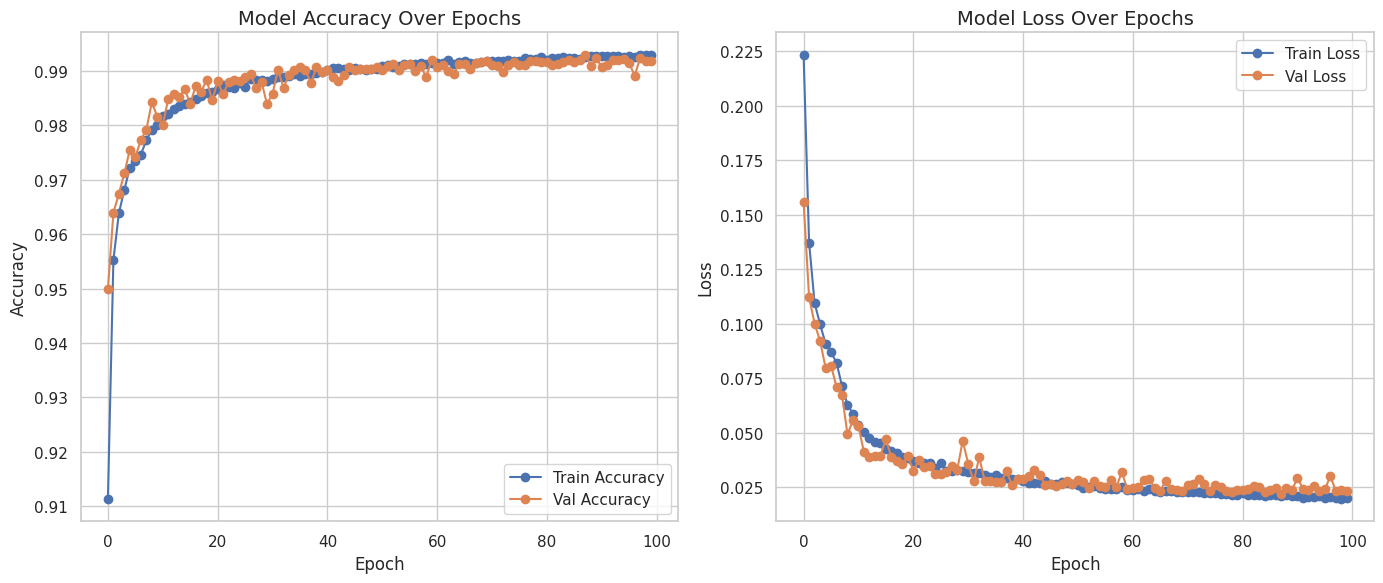

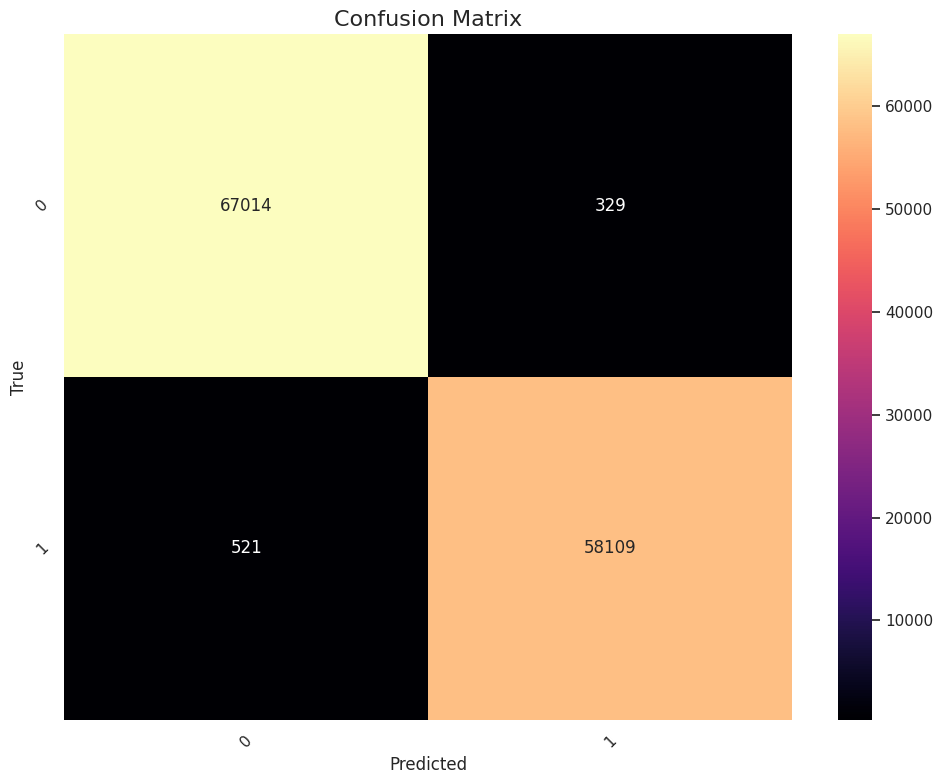

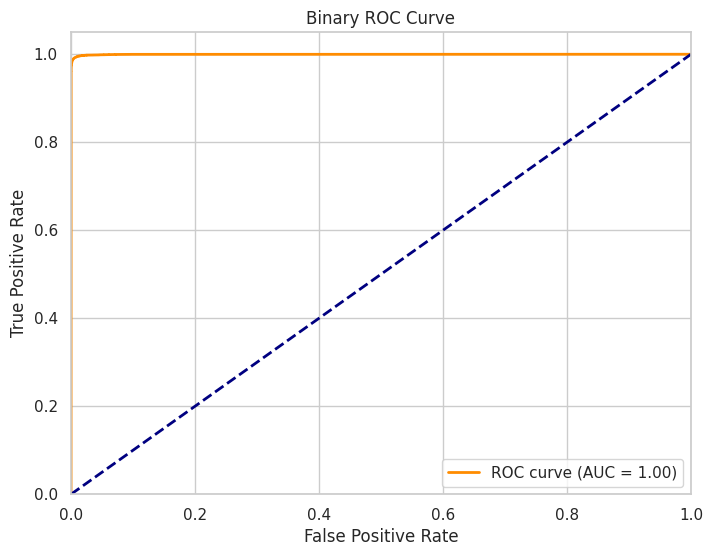

In [15]:
# Plot function
def plot_learning_curve(history):
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 6))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
    plt.title('Model Accuracy Over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
    plt.title('Model Loss Over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curve(history)

def plot_conf_matrix(y_true, y_pred, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=class_labels, yticklabels=class_labels)
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Define class labels
class_labels = [str(cls) for cls in np.unique(y_final_test)]
plot_conf_matrix(y_final_test, y_pred, class_labels)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_binary_roc(y_true, y_score):
    if y_score.ndim > 1:
        y_score = y_score[:, 1]  # probability for positive class
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Binary ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_binary_roc(y_final_test, predictions)
